# SINIFLANDIRMA 

In [49]:
# uyarıları gizleme
import warnings
warnings.filterwarnings('ignore')

# pandas kütüphanesi ekleme
!pip install pandas 

In [50]:
!pip install seaborn

### Gerekli kütüphaneleri proje dosyasına ekleme

In [51]:
# - pandas: Veri işleme ve analiz için
# - train_test_split: Veriyi eğitim ve test setlerine ayırmak için
# - RandomForestClassifier: Sınıflandırma işlemi için Random Forest algoritması
# - accuracy_score, classification_report: Model başarımını değerlendirmek için
from sklearn.model_selection import train_test_split  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score  
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

## 1. VERİ SETİNİ YÜKLEME

In [52]:
# Daha önce oluşturduğumuz CSV dosyasını pandas ile okuyoruz
# 'df' adında bir DataFrame oluşturuluyoruz
df = pd.read_csv("csv_data/test_siniflandirma.csv", encoding='utf-8')

In [53]:
df

,GÜN,RÜZGAR HIZI (KM/SAAT),Sıcaklık (°C),Nem Seviyesi (%),Yağmur Olasılığı (%),Uçuş Başarısı (%)
0,2,15.000000,22.0,21.000000,27.0,79.875000
1,3,11.000000,21.0,89.000000,43.0,71.625000
2,4,6.000000,6.0,59.615385,53.0,97.600000
3,6,25.000000,12.0,61.000000,72.0,77.150000
4,10,17.000000,27.0,71.000000,28.0,82.500000
...,...,...,...,...,...,...
134,193,7.000000,22.0,54.000000,26.0,90.000000
135,194,58.000000,38.0,10.000000,29.0,38.791667
136,195,33.000000,0.0,62.000000,68.0,70.600000
137,197,24.169355,21.0,66.000000,21.0,87.455645


## 2. VERİ HAZIRLAMA

In [54]:
# Uçuş başarısı değişkenlerin değerlerini %80 üzerindekiler 1, altındakiler 0 olacak şekilde düzenliyoruz. 
# Örnek: Başarı oranı >= %80
threshold = 80  
df['Uçuş Başarısı (Sınıf)'] = (df['Uçuş Başarısı (%)'] >= threshold).astype(int)

In [55]:
# Özellikleri (X) ve hedef değişken (y) olarak ayırıyoruz.
# - X: Modelin girdi özellikleri ("RÜZGAR HIZI (KM/SAAT)", "Sıcaklık (°C)", "Nem Seviyesi (%)", "Yağmur Olasılığı (%)" sütunları).
# - Y: Modelin çıktı özellikleri ("Uçuş Başarısı (%)" sütunları).

# Bağımsız ve bağımlı değişkenleri ayırıyoruz.
X = df[["RÜZGAR HIZI (KM/SAAT)", "Sıcaklık (°C)", "Nem Seviyesi (%)", "Yağmur Olasılığı (%)"]] 
y = df["Uçuş Başarısı (%)"]

result_file_path = "csv_data/test_siniflandirma_1.csv"
df.to_csv(result_file_path, index=False)
print(f"Tahmin sonuçları '{result_file_path}' dosyasına kaydedildi.")

Tahmin sonuçları 'test_siniflandirma_1.csv' dosyasına kaydedildi.


In [56]:
df

,GÜN,RÜZGAR HIZI (KM/SAAT),Sıcaklık (°C),Nem Seviyesi (%),Yağmur Olasılığı (%),Uçuş Başarısı (%),Uçuş Başarısı (Sınıf)
0,2,15.000000,22.0,21.000000,27.0,79.875000,0
1,3,11.000000,21.0,89.000000,43.0,71.625000,0
2,4,6.000000,6.0,59.615385,53.0,97.600000,1
3,6,25.000000,12.0,61.000000,72.0,77.150000,0
4,10,17.000000,27.0,71.000000,28.0,82.500000,1
...,...,...,...,...,...,...,...
134,193,7.000000,22.0,54.000000,26.0,90.000000,1
135,194,58.000000,38.0,10.000000,29.0,38.791667,0
136,195,33.000000,0.0,62.000000,68.0,70.600000,0
137,197,24.169355,21.0,66.000000,21.0,87.455645,1


### • "Uçuş Başarısı (Sınıf)" Sütününün Yüzdelik Dağılımı

In [57]:
# "Uçuş Başarısı (Sınıf)" sütununun yüzdelik dağılımını hesapla
success_distribution = df['Uçuş Başarısı (Sınıf)'].value_counts(normalize=True) * 100

# Yüzdelik dağılımı yazdır
print(success_distribution)

Uçuş Başarısı (Sınıf)
1    61.151079
0    38.848921
Name: proportion, dtype: float64


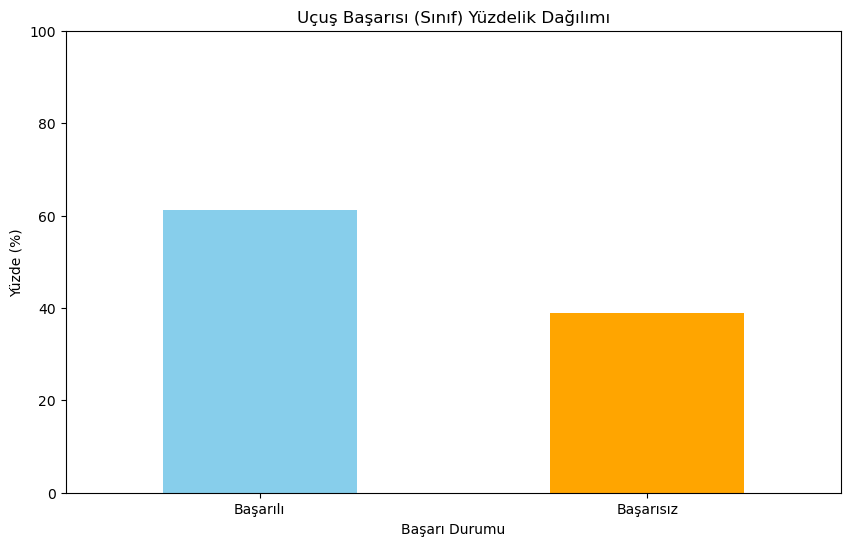

In [58]:
# Yüzdelik dağılımı görselleştir
plt.figure(figsize=(10, 6))
success_distribution.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Uçuş Başarısı (Sınıf) Yüzdelik Dağılımı')
plt.xlabel('Başarı Durumu')
plt.ylabel('Yüzde (%)')
plt.xticks([0, 1], ['Başarılı', 'Başarısız'], rotation=0)
plt.ylim(0, 100)
plt.show()

### • Rüzgar Hızı'nın Başarı'ya Olan Etkisi

In [59]:
# "RÜZGAR HIZI (KM/SAAT)" ve "Uçuş Başarısı (Sınıf)"'a göre, aralıkları tanımlayıp grupla
bins = [0, 15, 30, 45, 61]
labels = ['0-15', '15-30', '30-45', '45-60']

# 'RÜZGAR HIZI (KM/SAAT)' sütununa göre aralıklar oluştur
df['Rüzgar Hızı Aralığı'] = pd.cut(df['RÜZGAR HIZI (KM/SAAT)'], bins=bins, labels=labels, right=False)

# Başarı ve başarısızlık oranlarını pivot table ile yeniden düzenle
success_rate_by_wind_speed = df.groupby(['Rüzgar Hızı Aralığı', 'Uçuş Başarısı (Sınıf)']).size().unstack(fill_value=0)

# Oranları normalize et
success_rate_by_wind_speed = success_rate_by_wind_speed.div(success_rate_by_wind_speed.sum(axis=1), axis=0) * 100

print(success_rate_by_wind_speed)

Uçuş Başarısı (Sınıf)          0          1
Rüzgar Hızı Aralığı                        
0-15                   29.729730  70.270270
15-30                  29.411765  70.588235
30-45                  47.058824  52.941176
45-60                  88.235294  11.764706


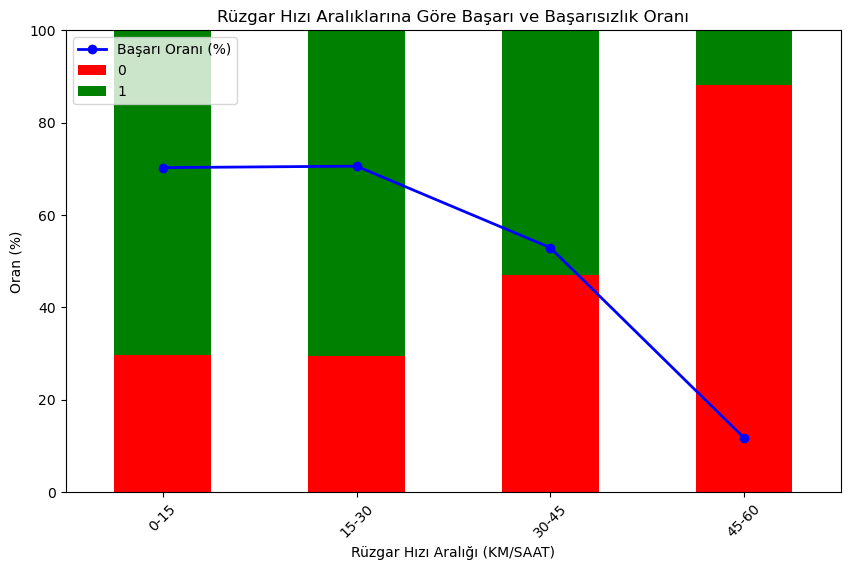

In [60]:
# Başarı oranlarını hesapla (Sadece "Başarı" oranı)
success_rates = success_rate_by_wind_speed[1]  # Sınıf "1" için oran

# Stacked bar plot çiz
success_rate_by_wind_speed.plot(kind='bar', stacked=True, color=['red', 'green'], figsize=(10, 6))

# Başarı oranlarını gösteren mavi çizgi grafiği ekle
x_positions = np.arange(len(labels))  # Barların merkez pozisyonları
plt.plot(x_positions, success_rates, marker='o', color='blue', linewidth=2, label='Başarı Oranı (%)')

# Grafik başlıkları ve etiketleri
plt.title('Rüzgar Hızı Aralıklarına Göre Başarı ve Başarısızlık Oranı')
plt.xlabel('Rüzgar Hızı Aralığı (KM/SAAT)')
plt.ylabel('Oran (%)')
plt.xticks(x_positions, labels, rotation=45)
plt.ylim(0, 100)
plt.legend()

# Göster
plt.show()

### • Yağmur Olasılığı'nın Başarı'ya Olan Etkisi

In [61]:
# "Yağmur Olasılığı (%)" ve "Uçuş Başarısı (Sınıf)"'a göre, aralıkları tanımlayıp grupla
bins = [0, 25, 50, 75, 101]
labels = ['0-25', '25-50', '50-75', '75-100']

# 'Yağmur Olasılığı (%)' sütununa göre aralıklar oluştur
df['Yağmur Olasılığı Aralığı'] = pd.cut(df['Yağmur Olasılığı (%)'], bins=bins, labels=labels, right=False)

# Başarı ve başarısızlık oranlarını pivot table ile yeniden düzenle
success_rate_by_wind_speed = df.groupby(['Yağmur Olasılığı Aralığı', 'Uçuş Başarısı (Sınıf)']).size().unstack(fill_value=0)

# Oranları normalize et
success_rate_by_wind_speed = success_rate_by_wind_speed.div(success_rate_by_wind_speed.sum(axis=1), axis=0) * 100

print(success_rate_by_wind_speed)

Uçuş Başarısı (Sınıf)              0          1
Yağmur Olasılığı Aralığı                       
0-25                       16.901408  83.098592
25-50                      53.191489  46.808511
50-75                      66.666667  33.333333
75-100                    100.000000   0.000000


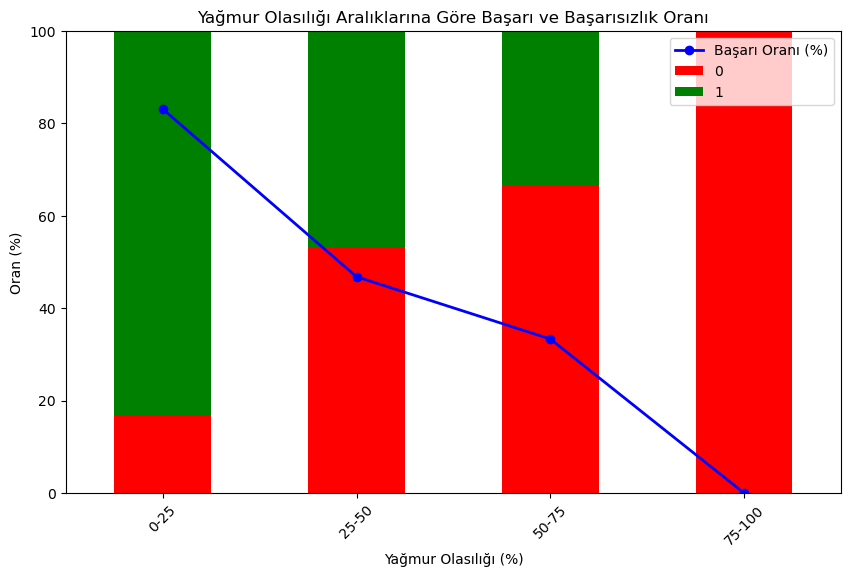

In [62]:
# Başarı oranlarını hesapla (Sadece "Başarı" oranı)
success_rates = success_rate_by_wind_speed[1]  # Sınıf "1" için oran

# Stacked bar plot çiz
success_rate_by_wind_speed.plot(kind='bar', stacked=True, color=['red', 'green'], figsize=(10, 6))

# Başarı oranlarını gösteren mavi çizgi grafiği ekle
x_positions = np.arange(len(labels))  # Barların merkez pozisyonları
plt.plot(x_positions, success_rates, marker='o', color='blue', linewidth=2, label='Başarı Oranı (%)')

# Grafik başlıkları ve etiketleri
plt.title('Yağmur Olasılığı Aralıklarına Göre Başarı ve Başarısızlık Oranı')
plt.xlabel('Yağmur Olasılığı (%)')
plt.ylabel('Oran (%)')
plt.xticks(x_positions, labels, rotation=45)
plt.ylim(0, 100)
plt.legend()
# Göster
plt.show()

### • Sıcaklık'ın Başarı'ya Olan Etkisi

In [63]:
# "Sıcaklık (°C)" ve "Uçuş Başarısı (Sınıf)"'a göre, aralıkları tanımlayıp grupla
bins = [-10, 2, 37, 41]
labels = ['-11-2', '2-37', '37-40']

# 'Sıcaklık (°C)' sütununa göre aralıklar oluştur
df['Sıcaklık (°C) Aralığı'] = pd.cut(df['Sıcaklık (°C)'], bins=bins, labels=labels, right=False)

# Başarı ve başarısızlık oranlarını pivot table ile yeniden düzenle
success_rate_by_wind_speed = df.groupby(['Sıcaklık (°C) Aralığı', 'Uçuş Başarısı (Sınıf)']).size().unstack(fill_value=0)

# Oranları normalize et
success_rate_by_wind_speed = success_rate_by_wind_speed.div(success_rate_by_wind_speed.sum(axis=1), axis=0) * 100

print(success_rate_by_wind_speed)

Uçuş Başarısı (Sınıf)          0          1
Sıcaklık (°C) Aralığı                      
-11-2                  76.923077  23.076923
2-37                   34.146341  65.853659
37-40                  66.666667  33.333333


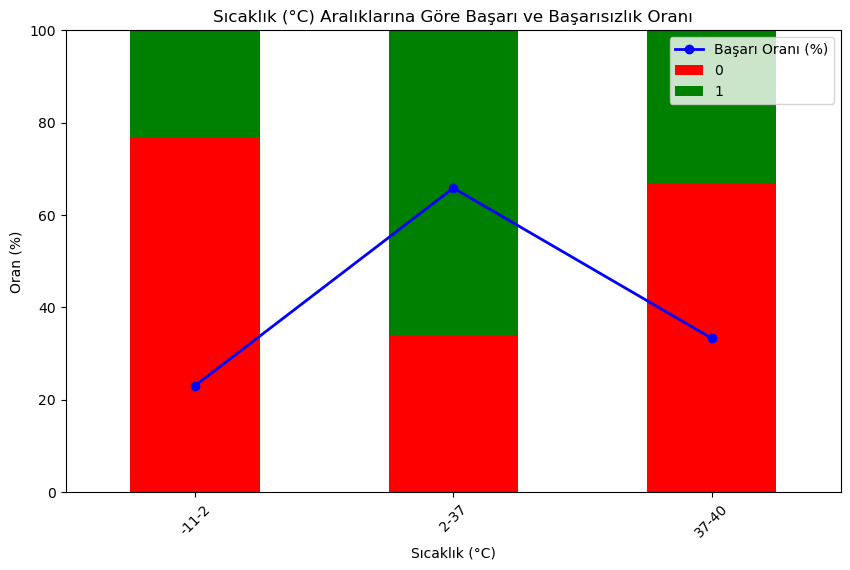

In [64]:
# Başarı oranlarını hesapla (Sadece "Başarı" oranı)
success_rates = success_rate_by_wind_speed[1]  # Sınıf "1" için oran

# Stacked bar plot çiz
success_rate_by_wind_speed.plot(kind='bar', stacked=True, color=['red', 'green'], figsize=(10, 6))

# Başarı oranlarını gösteren mavi çizgi grafiği ekle
x_positions = np.arange(len(labels))  # Barların merkez pozisyonları
plt.plot(x_positions, success_rates, marker='o', color='blue', linewidth=2, label='Başarı Oranı (%)')

# Grafik başlıkları ve etiketleri
plt.title('Sıcaklık (°C) Aralıklarına Göre Başarı ve Başarısızlık Oranı')
plt.xlabel('Sıcaklık (°C)')
plt.ylabel('Oran (%)')
plt.xticks(x_positions, labels, rotation=45)
plt.ylim(0, 100)
plt.legend()

# Göster
plt.show()

### • Nem Oranı'nın Başarı'ya Olan Etkisi

In [65]:
# "Nem Seviyesi (%)" ve "Uçuş Başarısı (Sınıf)"'a göre, aralıkları tanımlayıp grupla
bins = [0, 25, 50, 75, 101]
labels = ['0-25', '25-50', '50-75', '75-100']

# 'Nem Seviyesi (%)' sütununa göre aralıklar oluştur
df['Nem Seviyesi Olasılığı Aralığı'] = pd.cut(df['Nem Seviyesi (%)'], bins=bins, labels=labels, right=False)

# Başarı ve başarısızlık oranlarını pivot table ile yeniden düzenle
success_rate_by_wind_speed = df.groupby(['Nem Seviyesi Olasılığı Aralığı', 'Uçuş Başarısı (Sınıf)']).size().unstack(fill_value=0)

# Oranları normalize et
success_rate_by_wind_speed = success_rate_by_wind_speed.div(success_rate_by_wind_speed.sum(axis=1), axis=0) * 100

print(success_rate_by_wind_speed)

Uçuş Başarısı (Sınıf)                   0          1
Nem Seviyesi Olasılığı Aralığı                      
0-25                            54.545455  45.454545
25-50                           31.034483  68.965517
50-75                           31.818182  68.181818
75-100                          54.545455  45.454545


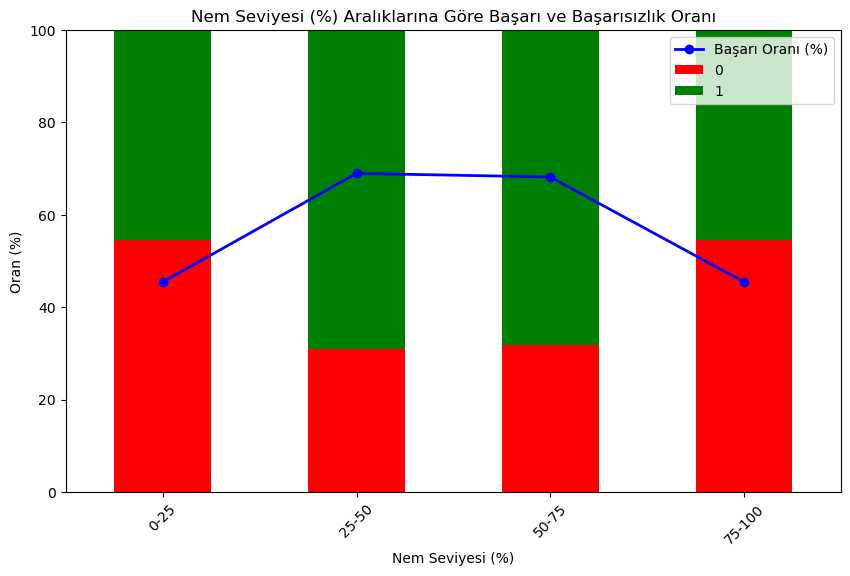

In [66]:
# Başarı oranlarını hesapla (Sadece "Başarı" oranı)
success_rates = success_rate_by_wind_speed[1]  # Sınıf "1" için oran

# Stacked bar plot çiz
success_rate_by_wind_speed.plot(kind='bar', stacked=True, color=['red', 'green'], figsize=(10, 6))

# Başarı oranlarını gösteren mavi çizgi grafiği ekle
x_positions = np.arange(len(labels))  # Barların merkez pozisyonları
plt.plot(x_positions, success_rates, marker='o', color='blue', linewidth=2, label='Başarı Oranı (%)')

# Grafik başlıkları ve etiketleri
plt.title('Nem Seviyesi (%) Aralıklarına Göre Başarı ve Başarısızlık Oranı')
plt.xlabel('Nem Seviyesi (%)')
plt.ylabel('Oran (%)')
plt.xticks(x_positions, labels, rotation=45)
plt.ylim(0, 100)
plt.legend()
# Göster
plt.show()

## 3. Model Oluşturma (Random Forest Sınıflandırıcısı)

In [67]:
print(y.unique())  # y değişkeninde hangi değerlerin olduğunu kontrol eder

[79.875      71.625      97.6        77.15       82.5        81.25
 81.         60.         55.         79.83333333 94.83064516 86.25
 94.         76.         79.33333333 77.5        87.01442308 82.76442308
 90.20564516 69.03064516 72.5        85.         90.         75.
 46.         81.5        85.375      86.01442308 87.76442308 92.125
 58.83064516 82.         84.5        87.375      88.         88.5
 66.86666667 79.75       82.95564516 91.         71.875      88.33333333
 83.875      71.5        70.125      74.375      87.8        82.01442308
 66.         72.375      90.75       94.58064516 78.25       47.65
 65.8        56.875      96.         92.5        76.875      54.70833333
 93.83064516 54.625      95.         98.5        73.01442308 87.875
 93.5        84.1        80.5        75.08333333 52.75       90.5
 80.75       87.25       83.125      84.8        55.375      82.75
 81.625      91.83064516 81.51442308 70.875      90.45564516 76.25
 64.83064516 84.25       99.         68.

In [68]:
y = df["Uçuş Başarısı (Sınıf)"]
print(y.unique())  # y değişkeninde hangi değerlerin olduğunu kontrol eder

[0 1]


In [69]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Verinizi yüklediğiniz yerden devam ediyoruz
# X, y, df gibi değişkenlerin zaten tanımlandığını varsayıyoruz.

# 3. Eğitim ve test setine bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 4. Model oluşturma ve eğitme
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Tahmin yapma
y_pred = model.predict(X_test)

# 6. Sonuçları değerlendirme
accuracy = accuracy_score(y_test, y_pred)
print(f"Modelin doğruluğu: {accuracy:.2f}")

# Sınıflandırma raporunu yazdırma
report = classification_report(y_test, y_pred, target_names=["Başarısız", "Başarılı"])
print("Sınıflandırma Raporu:")
print(report)

# 7. Tahmin edilen uçuş başarısını df'ye ekleme
# X_test'e karşılık gelen tahminleri yeni bir sütun olarak ekliyoruz.
# Ancak y_pred'in yalnızca X_test'e karşılık gelen tahminleri içerdiğini unutmamalısınız.
df['Tahmin Edilen Uçuş Başarısı'] = pd.NA  # İlk başta NaN değerler ekliyoruz
df.loc[X_test.index, 'Tahmin Edilen Uçuş Başarısı'] = y_pred  # Test verisinin indekslerini kullanarak tahminleri ekliyoruz

# 8. Sonuçları yeni bir CSV dosyasına kaydetme
output_file_path = 'csv_data/test_siniflandirma_2.csv'
df.to_csv(output_file_path, index=False, encoding='utf-8')


Modelin doğruluğu: 0.91
Sınıflandırma Raporu:
              precision    recall  f1-score   support

   Başarısız       0.84      0.89      0.86        18
    Başarılı       0.95      0.92      0.93        38

    accuracy                           0.91        56
   macro avg       0.89      0.90      0.90        56
weighted avg       0.91      0.91      0.91        56



In [70]:
df

,GÜN,RÜZGAR HIZI (KM/SAAT),Sıcaklık (°C),Nem Seviyesi (%),Yağmur Olasılığı (%),Uçuş Başarısı (%),Uçuş Başarısı (Sınıf),Rüzgar Hızı Aralığı,Yağmur Olasılığı Aralığı,Sıcaklık (°C) Aralığı,Nem Seviyesi Olasılığı Aralığı,Tahmin Edilen Uçuş Başarısı
0,2,15.000000,22.0,21.000000,27.0,79.875000,0,15-30,25-50,2-37,0-25,1
1,3,11.000000,21.0,89.000000,43.0,71.625000,0,0-15,25-50,2-37,75-100,<NA>
2,4,6.000000,6.0,59.615385,53.0,97.600000,1,0-15,50-75,2-37,50-75,<NA>
3,6,25.000000,12.0,61.000000,72.0,77.150000,0,15-30,50-75,2-37,50-75,<NA>
4,10,17.000000,27.0,71.000000,28.0,82.500000,1,15-30,25-50,2-37,50-75,1
...,...,...,...,...,...,...,...,...,...,...,...,...
134,193,7.000000,22.0,54.000000,26.0,90.000000,1,0-15,25-50,2-37,50-75,1
135,194,58.000000,38.0,10.000000,29.0,38.791667,0,45-60,25-50,37-40,0-25,0
136,195,33.000000,0.0,62.000000,68.0,70.600000,0,30-45,50-75,-11-2,50-75,<NA>
137,197,24.169355,21.0,66.000000,21.0,87.455645,1,15-30,0-25,2-37,50-75,1


### • Model Değerledirme

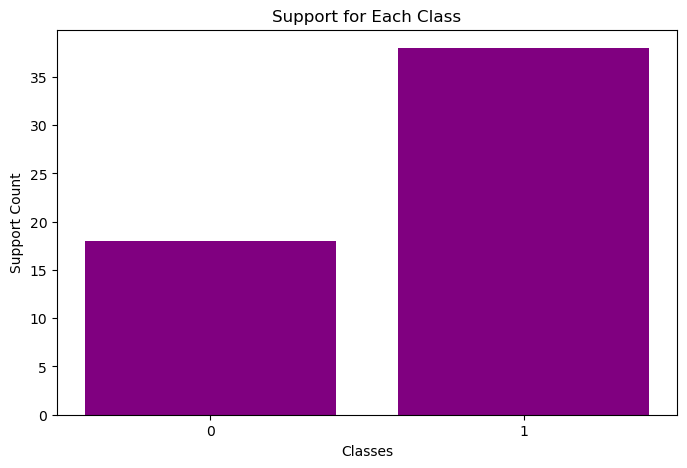

In [71]:
report = classification_report(y_test, y_pred, output_dict=True)
classes = list(report.keys())[:-3]  # "accuracy", "macro avg", "weighted avg" dışındaki sınıflar
support = [report[class_]["support"] for class_ in classes]

# 3. Support Grafiği
plt.figure(figsize=(8, 5))
plt.bar(classes, support, color='purple')
plt.title("Support for Each Class")
plt.xlabel("Classes")
plt.ylabel("Support Count")
plt.show()

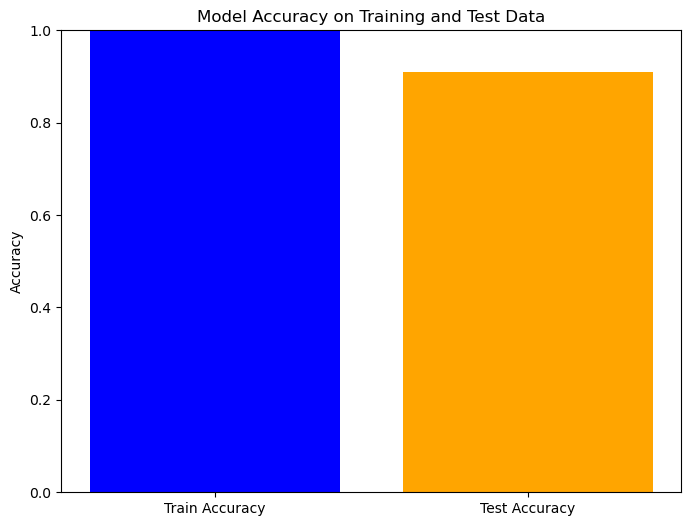

In [72]:
# Eğitim ve test doğruluğu
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy

# Eğitim ve Test Doğruluğu Grafiği
plt.figure(figsize=(8, 6))
plt.bar(["Train Accuracy", "Test Accuracy"], [train_accuracy, test_accuracy], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.title("Model Accuracy on Training and Test Data")
plt.ylabel("Accuracy")
plt.show()

In [73]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[16  2]
 [ 3 35]]


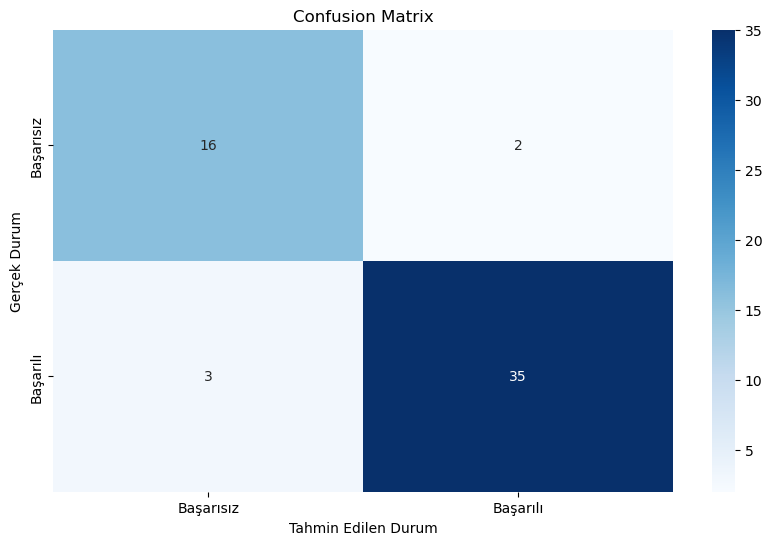

In [74]:
# 3. Görselleştirme
# Confusion Matrix Görselleştirme
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Başarısız", "Başarılı"], yticklabels=["Başarısız", "Başarılı"])
plt.title("Confusion Matrix")
plt.xlabel("Tahmin Edilen Durum")
plt.ylabel("Gerçek Durum")
plt.show()

In [75]:
# 'model' adında eğitilmiş modelimizi daha önce karşılaşılmamış verisetleri üzerinde denemek için bir dosya olarak kaydediyoruz.
joblib.dump(model, "random_forest_model.pkl")
print("Model başarıyla kaydedildi.")

Model başarıyla kaydedildi.


## 4. Modeli Daha Önce Karşılaşılmamış Data Üzerinde Çalıştırma

In [76]:
# 1. Yeni veri setini yükleme
# Daha önce oluşturulan "365_days_weather_data_classification.csv" dosyasını pandas ile okuyoruz
new_df = pd.read_csv("365_days_weather_data_classification.csv", encoding='utf-8')

threshold_new = 80
new_df['Uçuş Başarısı (Sınıf)'] = (new_df['Uçuş Başarısı (%)'] >= threshold_new).astype(int)

result_file_path = "csv_data/365_days_weather_classification_1.csv"
new_df.to_csv(result_file_path, index=False)
print(f"Tahmin sonuçları '{result_file_path}' dosyasına kaydedildi.")

Tahmin sonuçları '365_days_weather_classification_1.csv' dosyasına kaydedildi.


In [77]:
new_df

,Gün,RÜZGAR HIZI (KM/SAAT),Yağmur Olasılığı (%),Nem Seviyesi (%),Sıcaklık (°C),Uçuş Başarısı (%),Uçuş Başarısı (Sınıf)
0,1,33,15,62,29,91.875000,1
1,2,53,88,17,1,27.933333,0
2,3,21,65,55,23,87.000000,1
3,4,48,45,82,27,56.625000,0
4,5,11,1,51,34,98.500000,1
...,...,...,...,...,...,...,...
134,135,23,38,81,3,74.250000,0
135,136,24,66,92,-6,65.200000,0
136,137,34,64,70,10,80.300000,1
137,138,15,9,57,4,88.500000,1


In [78]:
# 1. Veri setini yükleme
new_df = pd.read_csv("csv_data/365_days_weather_classification_1.csv", encoding='utf-8')

# 2. Kaydedilen modeli yükleme
loaded_model = joblib.load("random_forest_model.pkl")

# 3. Tahmin yapma
# Model ile yeni veri üzerinde tahmin yapıyoruz
predictions = loaded_model.predict(new_df[["RÜZGAR HIZI (KM/SAAT)", "Sıcaklık (°C)", "Nem Seviyesi (%)", "Yağmur Olasılığı (%)"]])

# 4. Tahmin sonuçlarını 'prediction_labels' olarak atıyoruz
prediction_labels = predictions[:140]  # İlk 140 tahmini alıyoruz

# 5. 'Tahmin Edilen Uçuş Başarısı' sütununu ekliyoruz
new_df["Tahmin Edilen Uçuş Başarısı"] = prediction_labels

# 6. Tahmin sonuçlarını görüntüleme
print("Tahmin Sonuçları:")
print(new_df.head())  # İlk birkaç satırı yazdırıyoruz

# 7. Tahmin sonuçlarını yeni bir CSV dosyasına kaydetme
result_file_path = "csv_data/365_days_weather_classification_2.csv"
new_df.to_csv(result_file_path, index=False)
print(f"Tahmin sonuçları '{result_file_path}' dosyasına kaydedildi.")


Tahmin Sonuçları:
   Gün  RÜZGAR HIZI (KM/SAAT)  Yağmur Olasılığı (%)  Nem Seviyesi (%)  \
0    1                     33                    15                62   
1    2                     53                    88                17   
2    3                     21                    65                55   
3    4                     48                    45                82   
4    5                     11                     1                51   

   Sıcaklık (°C)  Uçuş Başarısı (%)  Uçuş Başarısı (Sınıf)  \
0             29          91.875000                      1   
1              1          27.933333                      0   
2             23          87.000000                      1   
3             27          56.625000                      0   
4             34          98.500000                      1   

   Tahmin Edilen Uçuş Başarısı  
0                            1  
1                            0  
2                            0  
3                            0  
4    

### • Model Değerledirme

In [79]:
accuracy = accuracy_score(new_df['Uçuş Başarısı (Sınıf)'], predictions)
print(f"Modelin doğruluğu: {accuracy:.2f}")
report = classification_report(new_df['Uçuş Başarısı (Sınıf)'], predictions, target_names=["Başarısız", "Başarılı"])
print(report)

Modelin doğruluğu: 0.83
              precision    recall  f1-score   support

   Başarısız       0.82      0.95      0.88        91
    Başarılı       0.85      0.60      0.71        48

    accuracy                           0.83       139
   macro avg       0.84      0.77      0.79       139
weighted avg       0.83      0.83      0.82       139



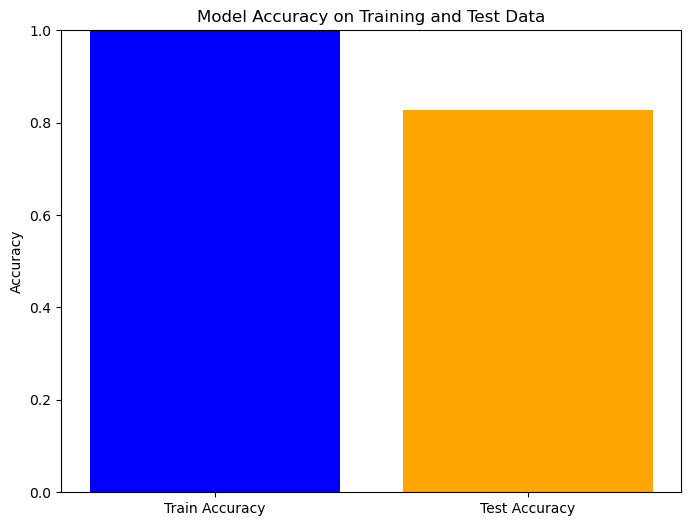

In [80]:
# Eğitim ve test doğruluğu
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy

# Eğitim ve Test Doğruluğu Grafiği
plt.figure(figsize=(8, 6))
plt.bar(["Train Accuracy", "Test Accuracy"], [train_accuracy, test_accuracy], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.title("Model Accuracy on Training and Test Data")
plt.ylabel("Accuracy")
plt.show()

In [81]:
# Confusion Matrix
conf_matrix = confusion_matrix(new_df['Uçuş Başarısı (Sınıf)'], predictions)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[86  5]
 [19 29]]


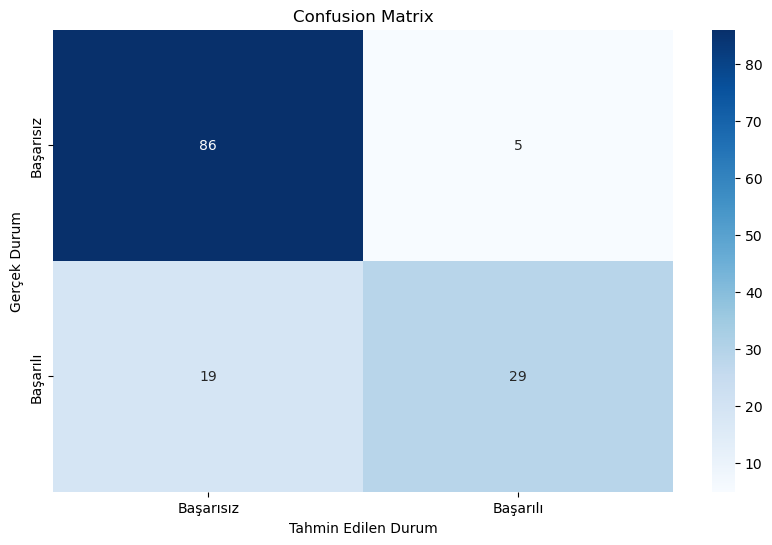

In [82]:
# 3. Görselleştirme
# Confusion Matrix Görselleştirme
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Başarısız", "Başarılı"], yticklabels=["Başarısız", "Başarılı"])
plt.title("Confusion Matrix")
plt.xlabel("Tahmin Edilen Durum")
plt.ylabel("Gerçek Durum")
plt.show()